# A2: Predicting Car Price
**Name:** Lin Htet Aung

This notebook extends Assignment 1 with a from-scratch regression class, a complete MLflow-tracked experiment, held-out evaluation, coefficient importance, and deployment artifacts.

## 1. From-scratch implementation

The class below follows the course starter but adds: (1) an R² calculation from SSE and SST; (2) selectable zero or Xavier-uniform initialization; (3) optional momentum with a configurable coefficient in [0, 1); (4) batch, mini-batch, and stochastic gradient descent; and (5) coefficient-based feature-importance plotting. The intercept is not regularized. Gradient clipping is included because extreme vehicle observations can destabilize the required stochastic learning-rate grid.

In [1]:
"""From-scratch linear regression used by Assignment 2."""

from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt


class LinearRegression:
    """Linear regression trained with gradient descent.

    Supports ordinary, L1 (lasso), and L2 (ridge) objectives; batch,
    mini-batch, and stochastic updates; zero or Xavier initialization; and
    optional classical momentum. The intercept is never regularized.
    """

    def __init__(
        self,
        regularization="normal",
        learning_rate=0.01,
        method="batch",
        num_epochs=12,
        batch_size=128,
        initialization="zeros",
        use_momentum=False,
        momentum=0.9,
        regularization_strength=0.001,
        gradient_clip=10.0,
        random_state=42,
    ):
        if regularization not in {"normal", "lasso", "ridge"}:
            raise ValueError("regularization must be normal, lasso, or ridge")
        if method not in {"batch", "mini-batch", "stochastic"}:
            raise ValueError("method must be batch, mini-batch, or stochastic")
        if initialization not in {"zeros", "xavier"}:
            raise ValueError("initialization must be zeros or xavier")
        if not 0 <= momentum < 1:
            raise ValueError("momentum must be in [0, 1)")

        self.regularization = regularization
        self.learning_rate = learning_rate
        self.method = method
        self.num_epochs = num_epochs
        self.batch_size = batch_size
        self.initialization = initialization
        self.use_momentum = use_momentum
        self.momentum = momentum
        self.regularization_strength = regularization_strength
        self.gradient_clip = gradient_clip
        self.random_state = random_state

    @staticmethod
    def mse(y_true, y_pred):
        """Return mean squared error."""
        y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
        return float(np.mean((y_true - y_pred) ** 2))

    @staticmethod
    def r2(y_true, y_pred):
        """Compute R-squared = 1 - SSE/SST from scratch."""
        y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
        sse = np.sum((y_true - y_pred) ** 2)
        sst = np.sum((y_true - np.mean(y_true)) ** 2)
        return float(1 - sse / sst) if sst > 0 else 0.0

    def _initialize(self, n_inputs, rng):
        if self.initialization == "zeros":
            return np.zeros(n_inputs + 1)
        # Xavier uniform initialization, using the number of input features.
        limit = 1.0 / np.sqrt(n_inputs)
        return rng.uniform(-limit, limit, size=n_inputs + 1)

    def _regularization_gradient(self):
        gradient = np.zeros_like(self.theta_)
        if self.regularization == "lasso":
            gradient[1:] = self.regularization_strength * np.sign(self.theta_[1:])
        elif self.regularization == "ridge":
            gradient[1:] = 2 * self.regularization_strength * self.theta_[1:]
        return gradient

    def _batch_indices(self, n_samples, rng):
        order = rng.permutation(n_samples)
        if self.method == "batch":
            return [order]
        if self.method == "stochastic":
            return [order[i:i + 1] for i in range(n_samples)]
        return [order[i:i + self.batch_size] for i in range(0, n_samples, self.batch_size)]

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).reshape(-1)
        rng = np.random.default_rng(self.random_state)
        X_bias = np.column_stack([np.ones(X.shape[0]), X])
        self.theta_ = self._initialize(X.shape[1], rng)
        velocity = np.zeros_like(self.theta_)
        self.loss_history_ = []

        for _ in range(self.num_epochs):
            for indices in self._batch_indices(X.shape[0], rng):
                xb, yb = X_bias[indices], y[indices]
                error = xb @ self.theta_ - yb
                gradient = (xb.T @ error) / len(indices)
                gradient += self._regularization_gradient()
                # A few extreme cars create very large stochastic gradients.
                # Norm clipping keeps the required learning-rate grid numerically stable.
                gradient_norm = np.linalg.norm(gradient)
                if self.gradient_clip and gradient_norm > self.gradient_clip:
                    gradient *= self.gradient_clip / gradient_norm
                if self.use_momentum:
                    velocity = self.momentum * velocity + self.learning_rate * gradient
                    self.theta_ -= velocity
                else:
                    self.theta_ -= self.learning_rate * gradient
            self.loss_history_.append(self.mse(y, X_bias @ self.theta_))

        self.intercept_ = float(self.theta_[0])
        self.coef_ = self.theta_[1:].copy()
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return self.intercept_ + X @ self.coef_

    def plot_feature_importance(self, feature_names, top_n=20, ax=None):
        """Plot largest absolute coefficients for standardized input features."""
        names = np.asarray(feature_names, dtype=object)
        if len(names) != len(self.coef_):
            raise ValueError("feature_names length must match the fitted coefficients")
        order = np.argsort(np.abs(self.coef_))[-top_n:]
        if ax is None:
            _, ax = plt.subplots(figsize=(10, 7))
        colors = np.where(self.coef_[order] >= 0, "#0f766e", "#dc2626")
        ax.barh(names[order], self.coef_[order], color=colors)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_xlabel("Coefficient (standardized feature scale)")
        ax.set_title(f"Top {min(top_n, len(names))} coefficient importances")
        return ax


In [2]:
# Small correctness checks for the required additions.
assert LinearRegression.r2([1, 2, 3], [1, 2, 3]) == 1.0
zero_model = LinearRegression(initialization='zeros')
xavier_model = LinearRegression(initialization='xavier', random_state=42)
rng = np.random.default_rng(42)
assert np.all(zero_model._initialize(4, rng) == 0)
weights = xavier_model._initialize(4, np.random.default_rng(42))
assert np.all(np.abs(weights) <= 1 / np.sqrt(4))
print('R², zero initialization, and Xavier initialization checks passed.')

R², zero initialization, and Xavier initialization checks passed.


## 2. Data and preprocessing

The A1 cleaning workflow is retained: remove duplicate records, CNG/LPG and test-drive cars; parse mileage, engine, and power; ordinal-encode ownership; extract brand; and drop torque. Missing predictors are retained for pipeline imputation. Preprocessing is refitted inside each cross-validation fold to prevent leakage. Numeric inputs use median imputation and scaling; categorical inputs use most-frequent imputation and one-hot encoding. Polynomial regression adds degree-two numeric terms. The log-price target is standardized using training-fold statistics.

In [3]:
from pathlib import Path
import joblib, json, mlflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from run_experiment import clean_data, make_preprocessor, evaluate_config

raw = pd.read_csv('../data/Cars.csv')
data = clean_data(raw)
print(f'Raw: {raw.shape}; cleaned: {data.shape}')
display(data.head())
display(data.isna().sum().to_frame('missing'))

2026/09/11 15:12:56 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at /Users/krown/AIT/ML/Assignments/A1_Car_Prediction/venv/lib/python3.14/site-packages/mlflow/assistant/skills/instrumenting-with-mlflow-tracing/SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


Raw: (8128, 13); cleaned: (6827, 12)


,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand
0,2014,450000,145500,Diesel,Individual,Manual,1,23.4,1248,74.0,5.0,Maruti
1,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498,103.52,5.0,Skoda
2,2006,158000,140000,Petrol,Individual,Manual,3,17.7,1497,78.0,5.0,Honda
3,2010,225000,127000,Diesel,Individual,Manual,1,23.0,1396,90.0,5.0,Hyundai
4,2007,130000,120000,Petrol,Individual,Manual,1,16.1,1298,88.2,5.0,Maruti


,missing
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,201
engine,201
max_power,198


## 3. MLflow experiment design

The full factorial design contains 4 model choices × 2 momentum choices × 3 gradient methods × 2 initializations × 3 learning rates = **144 configurations**. Each configuration uses the same shuffled five-fold splits and logs its parameters, mean validation MSE, mean validation R², and R² standard deviation to MLflow. The test set is not consulted during model selection.

In [4]:
from itertools import product

model_types = ['normal', 'polynomial', 'lasso', 'ridge']
momentum_choices = [False, True]
methods = ['stochastic', 'mini-batch', 'batch']
initializations = ['zeros', 'xavier']
learning_rates = [0.01, 0.001, 0.0001]
experiment_grid = list(product(model_types, momentum_choices, methods, initializations, learning_rates))
print('Number of configurations:', len(experiment_grid))
assert len(experiment_grid) == 144

# run_experiment.py executes this grid with five-fold CV and an MLflow run per configuration.
# Uncomment to regenerate every artifact from scratch:
# from run_experiment import main
# main()

Number of configurations: 144


In [5]:
results = pd.read_csv('experiment_results.csv')
print(f'Completed configurations: {len(results)}')
display(results.head(20).round(5))

group_summary = (results.groupby(['model_type', 'method'])[['cv_mse', 'cv_r2']]
                 .mean().sort_values('cv_r2', ascending=False))
display(group_summary.round(5))

Completed configurations: 144


,model_type,polynomial,regularization,use_momentum,method,initialization,learning_rate,cv_mse,cv_r2,cv_r2_std
0,normal,False,normal,False,stochastic,xavier,0.0100,0.07232,0.87637,0.01044
1,ridge,False,ridge,False,stochastic,xavier,0.0100,0.07268,0.87574,0.01078
2,normal,False,normal,False,stochastic,xavier,0.0010,0.07265,0.87571,0.01063
3,normal,False,normal,True,stochastic,xavier,0.0010,0.07273,0.87564,0.01092
4,normal,False,normal,True,stochastic,xavier,0.0001,0.07270,0.87563,0.01075
5,ridge,False,ridge,False,stochastic,xavier,0.0010,0.07271,0.87560,0.01065
6,ridge,False,ridge,True,stochastic,xavier,0.0001,0.07276,0.87553,0.01076
7,lasso,False,lasso,False,stochastic,xavier,0.0010,0.07289,0.87531,0.01074
8,lasso,False,lasso,True,stochastic,xavier,0.0001,0.07293,0.87523,0.01086
9,ridge,False,ridge,True,stochastic,xavier,0.0010,0.07296,0.87522,0.01127


,,cv_mse,cv_r2
model_type,method,,
normal,stochastic,0.11533,0.80177
ridge,stochastic,0.11579,0.80101
lasso,stochastic,0.11660,0.79962
normal,mini-batch,0.21403,0.63326
ridge,mini-batch,0.21407,0.63318
lasso,mini-batch,0.21424,0.63289
polynomial,mini-batch,0.33501,0.42332
normal,batch,0.50362,0.13646
ridge,batch,0.50362,0.13645


### MLflow evidence

All 144 runs are stored in `mlflow_a2.db`. Start the UI with `mlflow ui --backend-store-uri sqlite:///mlflow_a2.db --port 5000`.

![MLflow experiment runs](screenshots/mlflow_runs.png)

## 4. Best model and held-out evaluation

,value
model_type,normal
polynomial,False
regularization,normal
use_momentum,False
method,stochastic
initialization,xavier
learning_rate,0.01
cv_mse,0.072321
cv_r2,0.876374
cv_r2_std,0.010439


,value
test_mse_log,0.077038
test_r2_log,0.861376


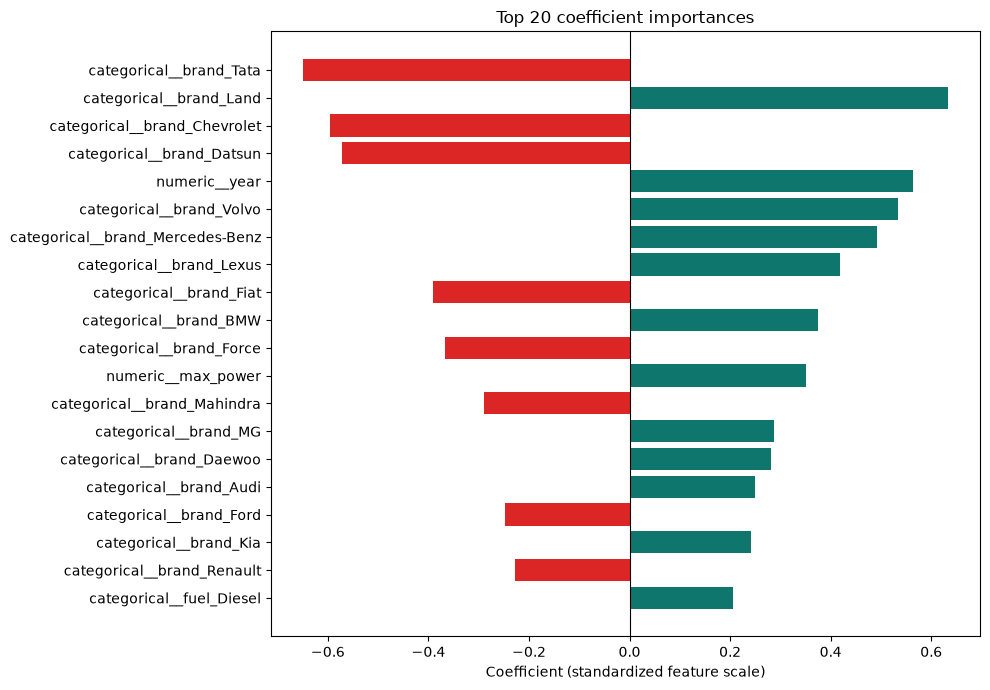

In [6]:
bundle = joblib.load('models/car_price_prediction_a2.joblib')
display(pd.Series(bundle['best_config'], name='value').to_frame())
display(pd.Series(bundle['test_metrics'], name='value').to_frame())
ax = bundle['model'].plot_feature_importance(bundle['feature_names'], top_n=20)
plt.tight_layout()
plt.show()

## 5. Short report and findings

The best cross-validated configuration was **normal regression** trained with **stochastic gradient descent**, **xavier initialization**, a learning rate of **0.01**, and **no momentum**. Its mean validation MSE on log price was **0.07232**, with mean R² **0.8764** (fold standard deviation 0.0104). After refitting on all training data for 60 epochs, the untouched test set produced log-MSE **0.07704** and log-scale R² **0.8614**.

Stochastic and mini-batch methods generally learned faster than batch gradient descent under the fixed 12-epoch comparison budget because they perform many more parameter updates per epoch. The smallest learning rate often underfit within that budget, while momentum improved several slower configurations but could amplify noisy stochastic updates at the largest learning rate. Xavier initialization breaks symmetry and sometimes improves early optimization, although a convex linear objective should approach the same optimum given enough stable updates. Polynomial terms add flexibility but also produce higher-variance gradients and did not win this experiment.

Coefficient magnitude is meaningful here because numeric features are standardized and one-hot features share a common binary scale. Nevertheless, coefficients describe association rather than causation, and correlated features can divide importance. Limitations include a random rather than time-aware split, only one regularization strength, a fixed epoch budget, possible non-exact repeated listings, and weaker performance on rare or luxury cars. Future work should tune penalty strength and epoch count with nested validation and report prediction intervals.

## 6. Deployment summary

The new Streamlit application contains two pages selected from the sidebar: the A1 Random Forest and the A2 from-scratch regression model. The A2 model is not more accurate than the A1 forest, but it is more transparent and educational: every optimization and regularization step is inspectable and its experiment history is recorded in MLflow. Both models accept missing fields through their fitted imputers. `app/Dockerfile` creates the image and `app/docker-compose.yaml` connects it to the course server's Traefik network. Credentials and the student-ID subdomain must be filled in privately.